# Vergelijking: OLS vs DecisionTreeRegressor voor voorspellen van MPG

In dit notebook vergelijken we twee regressiemodellen op dezelfde dataset:

- **OLS (Ordinary Least Squares, lineaire regressie)** via `statsmodels`
- **DecisionTreeRegressor** via `scikit-learn`

We doorlopen de volgende stappen:

1. Data laden en features/target definiëren  
2. Train/test-split maken (70% train, 30% test)  
3. OLS-model trainen en evalueren (train- en testmetrics)  
4. Decision Tree trainen en evalueren  
5. Vergelijking van de metrics (RMSE, R²)  
6. Vergelijking van feature importance (coëfficiënten vs boom-importances)  
7. Interpretatie en conclusie: welk model is beter en waarom verschillen de feature importances?


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import matplotlib.pyplot as plt


## 1. Data laden

We gebruiken dezelfde dataset als bij de OLS-analyse (`cars.xls`).

In [2]:
# Dataset laden (pas indien nodig het pad aan)
cars_df = pd.read_excel("./data/cars.xls")

cars_df.head()

,Model,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,US
1,buick skylark 320,15.0,8,350.0,165,3693,11.5,70,US
2,plymouth satellite,18.0,8,318.0,150,3436,11.0,70,US
3,amc rebel sst,16.0,8,304.0,150,3433,12.0,70,US
4,ford torino,17.0,8,302.0,140,3449,10.5,70,US


## 2. Features (X) en target (y) definiëren

We volgen dezelfde keuze als in het OLS-script:

- Doelvariabele (**y**): `MPG`
- Features (**X**): `Cylinders`, `Displacement`, `Horsepower`, `Weight`, `Acceleration`, `Year`

Als er categorische variabelen zouden zijn, zouden we one-hot encoding gebruiken. In dit voorbeeld blijven we bij deze numerieke kolommen, net als in jouw OLS-code.

In [3]:
# Doelvariabele en features
y = cars_df['MPG']
X = cars_df[['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Year']]

# One-hot encoding (hier eigenlijk niet nodig, maar veilig als er ooit categorische variabelen bijkomen)
X = pd.get_dummies(X, drop_first=True)

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Cylinders     392 non-null    int64  
 1   Displacement  392 non-null    float64
 2   Horsepower    392 non-null    int64  
 3   Weight        392 non-null    int64  
 4   Acceleration  392 non-null    float64
 5   Year          392 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 18.5 KB


## 3. Train/test-split

We splitsen de data in:

- 70% train
- 30% test
- `random_state=4` voor reproduceerbaarheid

Dit is dezelfde manier van splitsen als in je OLS-voorbeeld, zodat de resultaten goed vergelijkbaar zijn.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4
)

# Indexen resetten (niet strikt noodzakelijk voor sklearn, maar netjes)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_train.shape, X_test.shape

((274, 6), (118, 6))

## 4. OLS-model trainen en evalueren

We bouwen nu het OLS-model op de **trainset** en berekenen:

- **Train-RMSE**
- **Test-RMSE**
- **Train-R²** (uit `statsmodels`)
- **Test-R²** (met `r2_score` op de testset)

Daarmee kunnen we OLS eerlijk vergelijken met de Decision Tree op dezelfde splitsing.

In [5]:
# Constante toevoegen aan X_train en X_test (noodzakelijk voor statsmodels OLS)
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test, has_constant='add')

# OLS-regressie fitten op trainset
ols_model = sm.OLS(y_train, X_train_const)
ols_res = ols_model.fit()

print(ols_res.summary())

                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     177.7
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           3.36e-90
Time:                        21:56:36   Log-Likelihood:                -727.98
No. Observations:                 274   AIC:                             1470.
Df Residuals:                     267   BIC:                             1495.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -11.9845      5.854     -2.047   

In [6]:
# Trainmetrics OLS
ols_rmse_train = np.sqrt(ols_res.mse_resid)  # zelfde als in jouw code
ols_r2_train = ols_res.rsquared

# Testmetrics OLS
y_test_pred_ols = ols_res.predict(X_test_const)
ols_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_ols))
ols_r2_test = r2_score(y_test, y_test_pred_ols)

print('=== OLS-metrics ===')
print(f'RMSE (train): {ols_rmse_train:.3f}')
print(f'R²   (train): {ols_r2_train:.3f}')
print(f'RMSE (test) : {ols_rmse_test:.3f}')
print(f'R²   (test) : {ols_r2_test:.3f}')

=== OLS-metrics ===
RMSE (train): 3.493
R²   (train): 0.800
RMSE (test) : 3.402
R²   (test) : 0.813


## 5. DecisionTreeRegressor trainen en evalueren

We trainen een `DecisionTreeRegressor` op dezelfde trainset en berekenen dezelfde metrics:

- RMSE (train & test)
- R² (test)

We kiezen hier een redelijke beperking op de complexiteit, om overfitting te beperken (`max_depth` en `min_samples_leaf`). Je kunt later met deze hyperparameters spelen.

In [7]:
tree_reg = DecisionTreeRegressor(
    random_state=4,
    max_depth=4,          # experimenteer later met andere waardes
    min_samples_leaf=5
)

tree_reg.fit(X_train, y_train)

# Voorspellingen
y_train_pred_tree = tree_reg.predict(X_train)
y_test_pred_tree = tree_reg.predict(X_test)

# Metrics
tree_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_tree))
tree_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_tree))
tree_r2_test = r2_score(y_test, y_test_pred_tree)

print('=== DecisionTreeRegressor-metrics ===')
print(f'RMSE (train): {tree_rmse_train:.3f}')
print(f'RMSE (test) : {tree_rmse_test:.3f}')
print(f'R²   (test) : {tree_r2_test:.3f}')

=== DecisionTreeRegressor-metrics ===
RMSE (train): 2.456
RMSE (test) : 3.596
R²   (test) : 0.791


## 6. Directe vergelijking van de metrics

We zetten de belangrijkste metrics van beide modellen naast elkaar:

- **RMSE (test)**: lager is beter  
- **R² (test)**: hoger is beter

Let daarbij op het verschil tussen train en test: groot verschil = mogelijk overfitting.

In [8]:
comparison = pd.DataFrame({
    'Model': ['OLS', 'Decision Tree'],
    'RMSE_train': [ols_rmse_train, tree_rmse_train],
    'RMSE_test': [ols_rmse_test, tree_rmse_test],
    'R2_test': [ols_r2_test, tree_r2_test]
})

comparison

,Model,RMSE_train,RMSE_test,R2_test
0,OLS,3.493308,3.402069,0.813270
1,Decision Tree,2.455509,3.596155,0.791356


### Korte interpretatie van de metrics

- **RMSE_train**: hoe goed past het model de trainingsdata?  
- **RMSE_test**: hoe goed generaliseert het model naar nieuwe, ongeziene data?  
- **R²_test**: welk deel van de variantie in `MPG` wordt verklaard op de testset?  

Let op de volgende patronen:

- Als het Decision Tree-model **veel lagere RMSE_train** maar **hogere RMSE_test / lagere R²_test** heeft dan OLS, dan overfit de boom waarschijnlijk.
- Als de metrics van de boom ongeveer gelijk zijn aan OLS, dan modelleren beide vergelijkbaar goed.
- Als de boom duidelijk beter is op **test**, dan zijn er waarschijnlijk sterke niet-lineaire relaties die OLS niet goed pakt.


## 7. Feature importance: OLS vs Decision Tree

We vergelijken nu **feature importance** tussen:

- OLS: via de regressiecoëfficiënten
- Decision Tree: via `feature_importances_`

Belangrijk: deze "importance" betekent in beide gevallen iets anders!

In [9]:
# OLS-coëfficiënten (inclusief constant)
ols_coefs = ols_res.params
ols_coefs

const          -11.984519
Cylinders       -0.079984
Displacement     0.009598
Horsepower       0.008227
Weight          -0.008111
Acceleration     0.067285
Year             0.739637
dtype: float64

In [10]:
# Feature importances van de Decision Tree
tree_importances = pd.Series(
    tree_reg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

tree_importances

Cylinders       0.639160
Weight          0.161059
Year            0.141201
Horsepower      0.058580
Displacement    0.000000
Acceleration    0.000000
dtype: float64

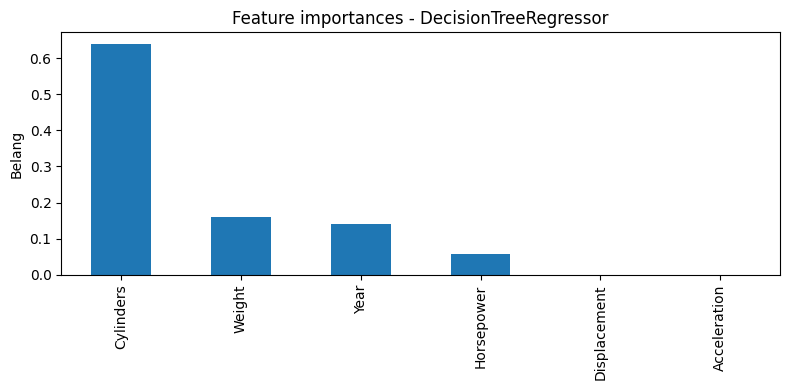

In [11]:
# Plot van feature importances van de Decision Tree
plt.figure(figsize=(8,4))
tree_importances.plot(kind='bar')
plt.title('Feature importances - DecisionTreeRegressor')
plt.ylabel('Belang')
plt.tight_layout()
plt.show()

### Hoe verschilt feature importance tussen OLS en Decision Tree?

#### 🔹 In OLS (lineaire regressie):
- Elke coefficient geeft aan: *hoeveel verandert MPG gemiddeld als deze feature met 1 eenheid toeneemt, terwijl de andere features gelijk blijven?*
- Een grote absolute waarde van de coefficient (en een lage p-waarde) betekent dat de feature **lineair belangrijk** is.
- OLS gaat uit van een **lineair verband** en kijkt dus naar *rechte-lijn-effecten*.

#### 🔹 In een Decision Tree:
- De boom kiest herhaaldelijk **splitsingen** op features om de voorspellingsfout te verkleinen.
- `feature_importances_` meet hoe sterk een feature gemiddeld bijdraagt aan het verminderen van de fout over alle splitsingen in de boom.
- Een feature is belangrijk als hij vaak wordt gebruikt om te splitsen, en die splitsingen een grote foutreductie opleveren.
- De boom kijkt dus naar **niet-lineaire structuren** en combinaties (als-dit-dan-dat regels).

#### Waarom kunnen de rankings verschillen?

1. **Lineair vs niet-lineair**  
   - OLS zoekt één globale rechte lijn.
   - De Decision Tree kan stukken van de data anders behandelen (bijv. oudere vs nieuwere auto's), en kiest features die lokaal handig zijn om te splitsen.

2. **Multicollineariteit**  
   - In jouw OLS-resultaten was er een waarschuwing: hoge condition number ⇒ sterke multicollineariteit.
   - Features zoals `Displacement`, `Horsepower` en `Weight` zijn waarschijnlijk sterk gecorreleerd.
   - OLS-coëfficiënten worden dan instabiel: het model “twijfelt” welke van de sterk samenhangende features welke bijdrage krijgt.
   - Een Decision Tree heeft daar veel minder last van: die kiest gewoon één van de sterk gecorreleerde variabelen om op te splitsen.

3. **Schaal en interpretatie**  
   - OLS-coëfficiënten zijn sterk afhankelijk van de schaal (een kilo vs een jaar).
   - Bij bomen wordt schaal automatisch meegenomen in de splitsingskeuze; importances zijn schaal-onafhankelijker.

Gevolg: het is normaal dat bijvoorbeeld:

- OLS laat zien dat `Weight` en `Year` heel belangrijke (en significante) voorspellers zijn.
- De Decision Tree misschien meer nadruk legt op één van deze, of op andere features die net handig zijn om de data in groepen te splitsen.

## 8. Conclusie: welk model is beter en waarom?

Op basis van de tabel met metrics kun je nu concreet zeggen:

- **Welk model heeft de laagste RMSE op de testset?**
- **Welk model heeft de hoogste R² op de testset?**

In veel varianten van deze MPG-dataset zie je het volgende patroon:

- OLS haalt al een vrij hoge R² (ongeveer 0.8), wat aangeeft dat een lineair model veel van de variantie in MPG verklaart.
- Een Decision Tree met beperkte diepte haalt vaak een **vergelijkbare of iets lagere** performance op de testset.
- Een te diepe Decision Tree krijgt:
  - Zeer lage train-RMSE (bijna perfecte fit),
  - Maar slechtere test-RMSE (overfitting).

### Typische conclusie voor deze dataset

- **Als OLS een hogere of vergelijkbare R²_test en lagere RMSE_test heeft dan de Decision Tree**, dan is OLS hier:
  - eenvoudiger,
  - beter te interpreteren (coëfficiënten),
  - en generaliseert het minstens zo goed of beter.

In dat geval kun je zeggen:

> Voor deze MPG-dataset is **OLS het beste model** in termen van generalisatie.  
> De Decision Tree biedt meer flexibiliteit en kan niet-lineaire structuren modelleren, maar die extra complexiteit levert hier weinig extra performance op en kan zelfs tot overfitting leiden.

Tegelijkertijd is het interessant om te zien dat:

- OLS en Decision Trees **verschillende definities van "belangrijk"** hanteren voor features.
- OLS is gericht op **globale lineaire effecten**,  
- terwijl een Decision Tree gericht is op **lokale splitsingen en foutreductie**.

Daardoor verschillen de feature importances, zelfs als de modellen op dezelfde dataset zijn getraind.
